In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

irradiance = pd.read_csv("data/irradiance_anonymized.csv")
pv_data = pd.read_csv("data/pv_data.csv", sep=";")
weather = pd.read_csv("data/weather.csv")

# To Datetime
irradiance["dt"] = pd.to_datetime(irradiance["dt_iso"])
pv_data["timestamp"] = pd.to_datetime(pv_data["timestamp"])
weather["time"] = pd.to_datetime(weather["time"])

# Set timezone to UTC
pv_data["timestamp"] = pv_data["timestamp"].dt.tz_localize("UTC")
weather["time"] = weather["time"].dt.tz_localize("UTC")


# Weather Data resolution 15min
weather.set_index('time', inplace=True)
new_index = pd.date_range(weather.index.min(), weather.index.max(), freq='15min')
weather_15min = weather.reindex(new_index)

num_cols = [
    'temperature_2m (°C)', 'cloud_cover (%)', 'wind_speed_10m (km/h)',
    'precipitation (mm)', 'relative_humidity_2m (%)', 'pressure_msl (hPa)',
    'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
    'wind_gusts_10m (km/h)'
]
weather_15min[num_cols] = weather_15min[num_cols].interpolate(method='time')

weather_15min['weather_code (wmo code)'] = weather_15min['weather_code (wmo code)'].ffill()

weather_15min.reset_index(inplace=True)
weather_15min.rename(columns={'index':'time'}, inplace=True)


In [9]:
pv_data[pv_data["Solarproduktion"] < 0]
#pv_data[pv_data["Solarproduktion"] > max_anlagenleistung]

,timestamp,Ladezustand,Batterie (Laden),Batterie (Entladen),Netzeinspeisung,Netzbezug,Solarproduktion Tracker 1,Solarproduktion Tracker 2,Solarproduktion Tracker 3,Solarproduktion,Hausverbrauch,Wallbox (ID 0) Gesamtladeleistung,Wallbox (ID 0) Netzbezug,Wallbox (ID 0) Solarladeleistung,Wallbox Gesamtladeleistung,Σ Verbrauch


## Strahlung

### Allgemeine Prüfung auf Ausreißer 

ghi_cloudy_sky: 0 negative Werte
dni_cloudy_sky: 0 negative Werte
dhi_cloudy_sky: 0 negative Werte
ghi_clear_sky: 0 negative Werte
dni_clear_sky: 0 negative Werte
dhi_clear_sky: 0 negative Werte
ghi_cloudy_sky 0
dni_cloudy_sky 0
dhi_cloudy_sky 0
ghi_clear_sky 0
dni_clear_sky 0
dhi_clear_sky 0
GHI Clear < Cloudy: 0
DNI Clear < Cloudy: 7338
DHI Clear < Cloudy: 26751


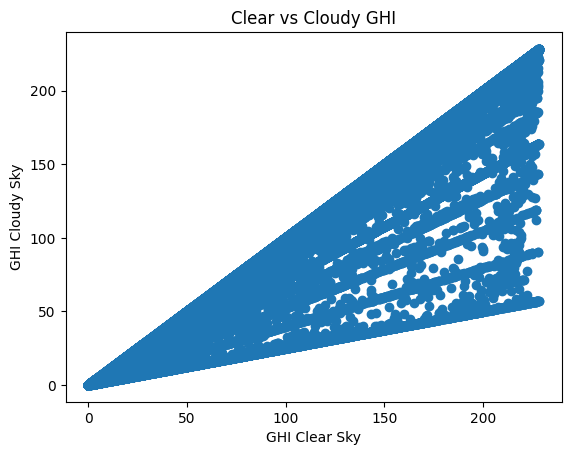

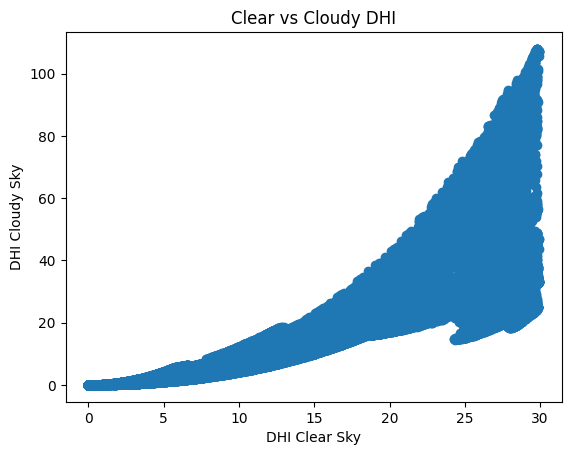

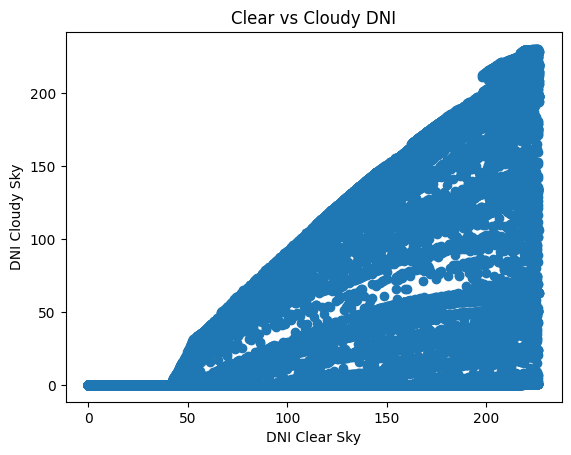

In [10]:
irradiance_cols = [
    "ghi_cloudy_sky",
    "dni_cloudy_sky",
    "dhi_cloudy_sky",
    "ghi_clear_sky",
    "dni_clear_sky",
    "dhi_clear_sky"
]

for col in irradiance_cols:
    negative_count = (irradiance[col] < 0).sum()
    print(f"{col}: {negative_count} negative Werte")

for col in irradiance_cols:
    print(col, (irradiance[col] > 1200).sum())


violations_ghi = (irradiance["ghi_clear_sky"] < irradiance["ghi_cloudy_sky"]).sum()
violations_dni = (irradiance["dni_clear_sky"] < irradiance["dni_cloudy_sky"]).sum()
violations_dhi = (irradiance["dhi_clear_sky"] < irradiance["dhi_cloudy_sky"]).sum()

print("GHI Clear < Cloudy:", violations_ghi)
print("DNI Clear < Cloudy:", violations_dni)
print("DHI Clear < Cloudy:", violations_dhi)

irradiance["ghi_diff"] = irradiance["ghi_clear_sky"] - irradiance["ghi_cloudy_sky"]
irradiance["dni_diff"] = irradiance["dni_clear_sky"] - irradiance["dni_cloudy_sky"]
irradiance["dhi_diff"] = irradiance["dhi_clear_sky"] - irradiance["dhi_cloudy_sky"]


irradiance[["ghi_diff", "dni_diff", "dhi_diff"]].describe()

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(irradiance["ghi_clear_sky"], irradiance["ghi_cloudy_sky"])
plt.xlabel("GHI Clear Sky")
plt.ylabel("GHI Cloudy Sky")
plt.title("Clear vs Cloudy GHI")
plt.show()

plt.figure()
plt.scatter(irradiance["dhi_clear_sky"], irradiance["dhi_cloudy_sky"])
plt.xlabel("DHI Clear Sky")
plt.ylabel("DHI Cloudy Sky")
plt.title("Clear vs Cloudy DHI")
plt.show()

plt.figure()
plt.scatter(irradiance["dni_clear_sky"], irradiance["dni_cloudy_sky"])
plt.xlabel("DNI Clear Sky")
plt.ylabel("DNI Cloudy Sky")
plt.title("Clear vs Cloudy DNI")
plt.show()

### Überprüfung von DNI und DHI

In [11]:
irradiance["dni_rel_diff"] = irradiance["dni_diff"] / irradiance["dni_clear_sky"]
irradiance["dhi_rel_diff"] = irradiance["dhi_diff"] / irradiance["dhi_clear_sky"]

irradiance[["dni_rel_diff", "dhi_rel_diff"]].describe()


,dni_rel_diff,dhi_rel_diff
count,59914.000000,59978.000000
mean,0.331782,-0.153956
std,0.399842,0.568308
min,-0.072117,-2.622565
25%,0.010753,-0.162250
50%,0.070415,0.021366
75%,0.715868,0.104030
max,1.000000,1.000000


In [12]:
irradiance[
    (irradiance["dhi_rel_diff"] < -1.5) &
    (irradiance["ghi_clear_sky"] > 20)
][["dhi_clear_sky", "dhi_cloudy_sky"]].head()

,dhi_clear_sky,dhi_cloudy_sky
1336,23.42,59.15
1430,23.34,58.46
1431,23.49,59.38
1432,23.57,59.90
1433,23.59,60.02


### Zeitliche Konsistenz

In [20]:
irradiance["dt"].diff().value_counts()

dt
0 days 00:15:00    117639
Name: count, dtype: int64

## Weather

### Allgemeine Prüfung

Ungültige Cloud-Cover-Werte: 0
cloud_cover (%): 0 ungültige Werte
cloud_cover_low (%): 0 ungültige Werte
cloud_cover_mid (%): 0 ungültige Werte
cloud_cover_high (%): 0 ungültige Werte
Ungültige Humidity-Werte: 0
Extrem hohe Windgeschwindigkeit: 0


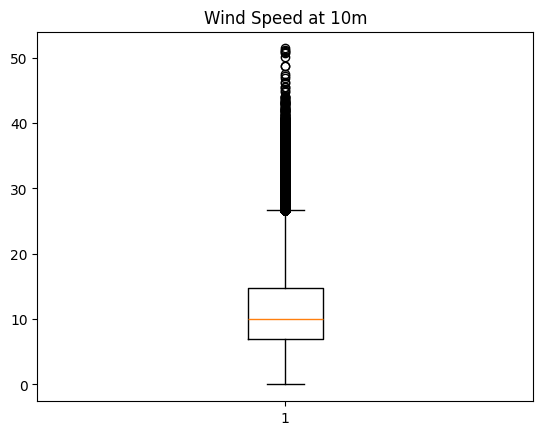

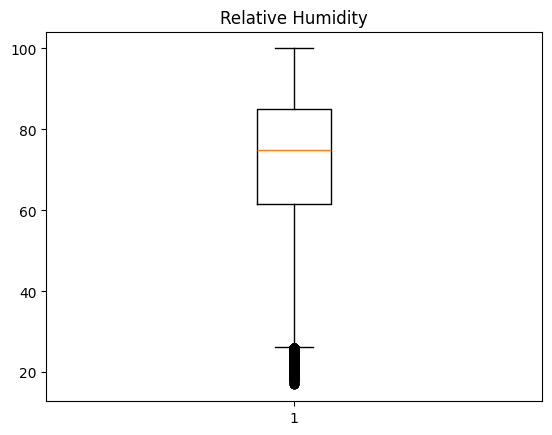

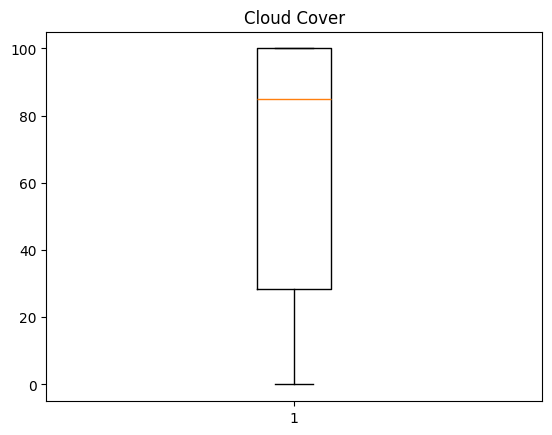

In [13]:
invalid_cloud = weather_15min[
    (weather_15min["cloud_cover (%)"] < 0) | 
    (weather_15min["cloud_cover (%)"] > 100)
]

print("Ungültige Cloud-Cover-Werte:", len(invalid_cloud))
invalid_cloud.head()

cloud_cols = [
    "cloud_cover (%)",
    "cloud_cover_low (%)",
    "cloud_cover_mid (%)",
    "cloud_cover_high (%)"
]

for col in cloud_cols:
    invalid = weather_15min[(weather_15min[col] < 0) | (weather_15min[col] > 100)]
    print(f"{col}: {len(invalid)} ungültige Werte")

invalid_humidity = weather_15min[
    (weather_15min["relative_humidity_2m (%)"] < 0) |
    (weather_15min["relative_humidity_2m (%)"] > 100)
]

print("Ungültige Humidity-Werte:", len(invalid_humidity))
invalid_humidity.head()

extreme_wind = weather_15min[weather_15min["wind_speed_10m (km/h)"] > 150]

print("Extrem hohe Windgeschwindigkeit:", len(extreme_wind))
extreme_wind.head()

checks = {
    "Cloud Cover <0 oder >100": weather_15min[
        (weather_15min["cloud_cover (%)"] < 0) |
        (weather_15min["cloud_cover (%)"] > 100)
    ].shape[0],
    
    "Humidity <0 oder >100": weather_15min[
        (weather_15min["relative_humidity_2m (%)"] < 0) |
        (weather_15min["relative_humidity_2m (%)"] > 100)
    ].shape[0],
    
    "Wind Speed >150": weather_15min[
        weather_15min["wind_speed_10m (km/h)"] > 150
    ].shape[0]
}

pd.Series(checks)


plt.boxplot(weather_15min["wind_speed_10m (km/h)"])
plt.title("Wind Speed at 10m")
plt.show()

plt.boxplot(weather_15min["relative_humidity_2m (%)"])
plt.title("Relative Humidity")
plt.show()

plt.boxplot(weather_15min["cloud_cover (%)"])
plt.title("Cloud Cover")
plt.show()


In [18]:
print("===== WIND SPEED DESCRIPTIVE STATS =====")
print(weather_15min["wind_speed_10m (km/h)"].describe())

print("\n===== WIND SPEED QUANTILES =====")
print(weather_15min["wind_speed_10m (km/h)"].quantile([0.95, 0.99, 0.999]))

weather_15min["cloud_diff"] = weather_15min["cloud_cover (%)"].diff()

print("\n===== GRÖSSTE CLOUD COVER SPRÜNGE =====")
print(
    weather_15min[["time", "cloud_cover (%)", "cloud_diff"]]
    .iloc[weather_15min["cloud_diff"].abs().sort_values(ascending=False).index[:5]]
)

===== WIND SPEED DESCRIPTIVE STATS =====
count    202077.000000
mean         11.431523
std           6.387469
min           0.000000
25%           6.900000
50%          10.050000
75%          14.800000
max          51.400000
Name: wind_speed_10m (km/h), dtype: float64

===== WIND SPEED QUANTILES =====
0.950    24.15
0.990    30.60
0.999    37.90
Name: wind_speed_10m (km/h), dtype: float64

===== GRÖSSTE CLOUD COVER SPRÜNGE =====
                            time  cloud_cover (%)  cloud_diff
148656 2024-03-28 12:00:00+00:00              0.0       -25.0
162808 2024-08-22 22:00:00+00:00              0.0       -25.0
180616 2025-02-24 10:00:00+00:00              0.0       -25.0
148892 2024-03-30 23:00:00+00:00              0.0       -25.0
115308 2023-04-16 03:00:00+00:00              0.0       -25.0


### Zeitliche Konsistenz

In [21]:
weather_15min["time"].diff().value_counts()

time
0 days 00:15:00    202076
Name: count, dtype: int64

## PV Data

### Algemeine Prüfung

In [15]:
checks = {
    "Netzbezug < 0": pv_data["Netzbezug"] < 0,
    "Netzeinspeisung < 0": pv_data["Netzeinspeisung"] < 0,
    "Σ Verbrauch < 0": pv_data["Σ Verbrauch"] < 0,
}

for name, condition in checks.items():
    print(f"{name}: {condition.sum()} Auffälligkeiten")



Netzbezug < 0: 0 Auffälligkeiten
Netzeinspeisung < 0: 0 Auffälligkeiten
Σ Verbrauch < 0: 0 Auffälligkeiten


### More Detail

In [16]:
pv_data[["Netzbezug", "Netzeinspeisung", "Σ Verbrauch"]].describe(percentiles=[0.01, 0.99])

,Netzbezug,Netzeinspeisung,Σ Verbrauch
count,113896.000000,113896.000000,113896.000000
mean,38.802829,159.446091,186.146204
std,169.318142,389.271960,272.762503
min,0.000000,0.000000,0.000000
1%,0.000000,0.000000,42.000000
50%,1.000000,1.000000,133.000000
99%,401.000000,1613.050000,1564.150000
max,3863.000000,2180.000000,3863.000000


### Zeitliche Konsistenz

In [24]:
pv_data["timestamp"].diff().value_counts()

timestamp
0 days 00:15:00    113856
1 days 00:15:00        39
Name: count, dtype: int64

In [27]:
gap_mask = pv_data["timestamp"].diff() > pd.Timedelta("15min")
gaps = pv_data.loc[gap_mask, "timestamp"]

gaps.head()



1960    2022-03-01 00:00:00+00:00
4840    2022-04-01 00:00:00+00:00
7624    2022-05-01 00:00:00+00:00
10504   2022-06-01 00:00:00+00:00
13288   2022-07-01 00:00:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

In [29]:
pv_data["dt"] = pv_data["timestamp"].diff()

valid_mask = pv_data["dt"].isin([
    pd.Timedelta("15min"),
    pd.NaT
])

pv_data_clean = pv_data[valid_mask].copy()

## Irgendwas ganz cooles

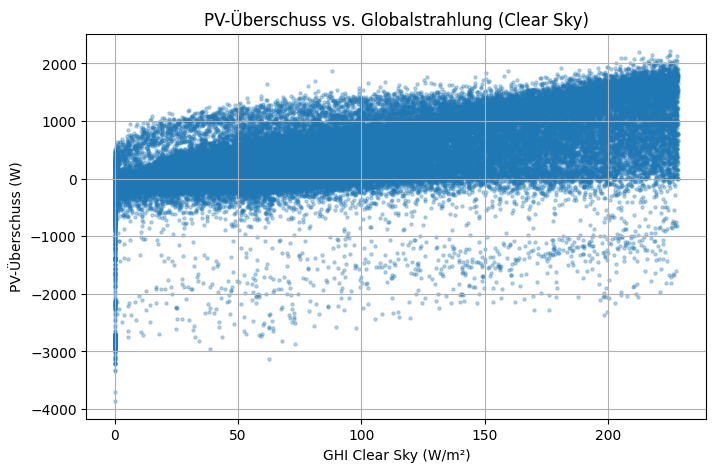

In [17]:
pv_data["pv_ueberschuss"] = pv_data["Solarproduktion"] - pv_data["Σ Verbrauch"]

df_merged = pd.merge(
    pv_data[["timestamp", "pv_ueberschuss"]],
    irradiance[["dt", "ghi_clear_sky"]],
    left_on="timestamp",
    right_on="dt",
    how="inner"
)

df_merged.drop(columns=["dt"], inplace=True)

plt.figure(figsize=(8,5))
plt.scatter(
    df_merged["ghi_clear_sky"],
    df_merged["pv_ueberschuss"],
    alpha=0.3,
    s=5
)

plt.xlabel("GHI Clear Sky (W/m²)")
plt.ylabel("PV-Überschuss (W)")
plt.title("PV-Überschuss vs. Globalstrahlung (Clear Sky)")
plt.grid(True)
plt.show()